# Übung · CNN auf Fashion-MNIST

In dieser Stunde trainierst du ein CNN auf **Fashion-MNIST** – einem integrierten
Datensatz aus **70.000 Graustufenbildern (28×28)** von Kleidungsstücken in 10 Klassen.
Er ist genauso aufgebaut wie MNIST, aber deutlich anspruchsvoller.

## So arbeitest du hier

Du **darfst** einen KI-Assistenten benutzen. Aber die Aufgaben sind bewusst so gebaut,
dass *Tippen nicht der Punkt ist*. Bewertet wird, ob du **vorhersagst, interpretierst,
entscheidest und Fehler findest** – also genau das, was man können muss, um
KI-geschriebenen Code zu beaufsichtigen. Fülle Code-Lücken gern mit Hilfe, aber
beantworte die Vorhersage- und Deutungsfelder **selbst**.

| Markierung | Was zu tun ist |
|---|---|
| 🔧 **Code-Lücke** | Code an der Stelle `___` ergänzen (KI-Hilfe erlaubt) |
| 🔮 **Vorhersage** | *vor* dem Ausführen schätzen und notieren |
| 🔍 **Deutung** | die tatsächliche Ausgabe interpretieren |
| ⚖️ **Entscheidung** | begründet auswählen |
| 🐞 **Fehlersuche** | lauffähigen, aber falschen Code finden & erklären |

Das Notebook läuft **nicht** per „Run all" durch – an den `___`-Stellen bricht es ab,
bis du sie ersetzt.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

# Haus-Stil (LFB KI BW)
DUNKELBLAU = "#1B3A5C"; MITTELBLAU = "#2E75B6"; ROT = "#C0392B"
plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.titlecolor"] = DUNKELBLAU
plt.rcParams["figure.dpi"]      = 110

KLASSEN = ['T-Shirt','Hose','Pullover','Kleid','Mantel',
           'Sandale','Hemd','Sneaker','Tasche','Stiefelette']

## A · Daten laden

`FashionMNIST` ist in `torchvision` integriert und wird beim ersten Aufruf
automatisch heruntergeladen. Für eine Unterrichtsstunde nehmen wir eine **Teilmenge**
(8.000 Training / 2.000 Test), damit das Training in Sekunden läuft.

In [2]:
transform = transforms.ToTensor()   # -> Tensor (1,28,28), Werte 0..1
train_ds = torchvision.datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

g = torch.Generator().manual_seed(42)
tr_idx = torch.randperm(len(train_ds), generator=g)[:8000]
te_idx = torch.randperm(len(test_ds),  generator=g)[:2000]
X_train = torch.stack([train_ds[i][0] for i in tr_idx]); y_train = torch.tensor([train_ds[i][1] for i in tr_idx])
X_test  = torch.stack([test_ds[i][0]  for i in te_idx]); y_test  = torch.tensor([test_ds[i][1]  for i in te_idx])
print("Training:", tuple(X_train.shape), "| Test:", tuple(X_test.shape))

Training: (8000, 1, 28, 28) | Test: (2000, 1, 28, 28)


## B · Explorative Datenanalyse (EDA)

Bevor wir modellieren, schauen wir uns die Daten an.

> 🔮 **Vorhersage 1.** Ist Fashion-MNIST **ausgewogen** (etwa gleich viele Bilder pro
> Klasse)? Schreibe deine Schätzung auf, *bevor* du die nächste Zelle ausführst.

T-Shirt     : 790
Hose        : 780
Pullover    : 841
Kleid       : 776
Mantel      : 830
Sandale     : 851
Hemd        : 803
Sneaker     : 781
Tasche      : 772
Stiefelette : 776


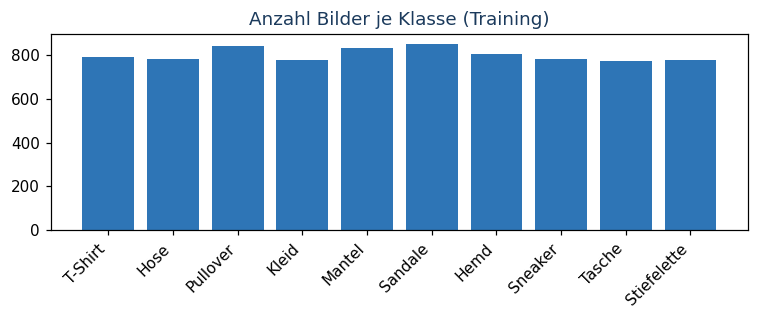

In [3]:
counts = torch.bincount(y_train, minlength=10)
for i, c in enumerate(counts):
    print(f"{KLASSEN[i]:12s}: {c.item()}")

plt.figure(figsize=(7,3))
plt.bar(KLASSEN, counts.numpy(), color=MITTELBLAU)
plt.xticks(rotation=45, ha="right"); plt.title("Anzahl Bilder je Klasse (Training)")
plt.tight_layout(); plt.show()

> 🔍 **Lösungshinweis (Vorhersage 1).** Der Datensatz ist **ausgewogen** – im
> Original genau 6.000 Bilder pro Klasse, in unserer Zufalls-Teilmenge je ca. 800.
> Ausgewogene Klassen sind günstig: Genauigkeit ist hier eine faire Kennzahl, und wir
> müssen das Training nicht gegen eine Übermacht-Klasse absichern.

Ein Blick auf je ein Beispiel pro Klasse:

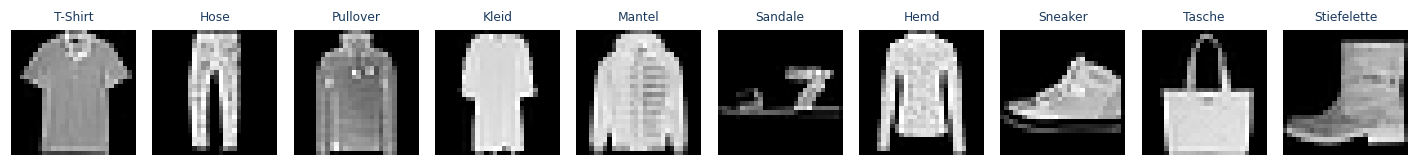

In [4]:
fig, axs = plt.subplots(1, 10, figsize=(13, 1.6))
for k in range(10):
    i = (y_train == k).nonzero()[0].item()
    axs[k].imshow(X_train[i,0], cmap="gray")
    axs[k].set_title(KLASSEN[k], fontsize=8); axs[k].axis("off")
plt.tight_layout(); plt.show()

Und das **Durchschnittsbild** je Klasse (Mittelwert aller Trainingsbilder einer
Klasse) – es zeigt die „typische Form".

> 🔍 **Deutung 1.** Welche **zwei oder drei Klassen** sehen sich am ähnlichsten?
> Stelle eine **Hypothese** auf, welche das Netz später wahrscheinlich verwechselt.

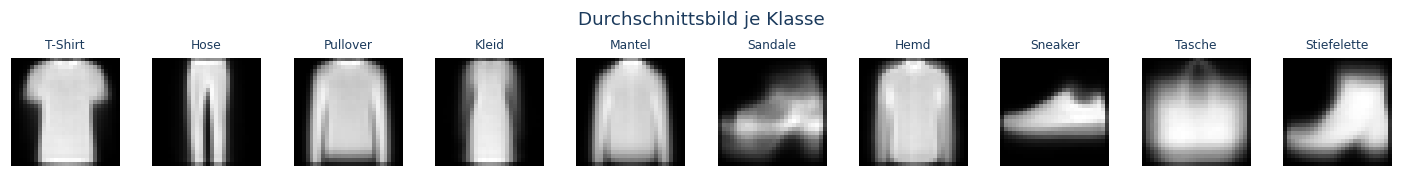

In [5]:
fig, axs = plt.subplots(1, 10, figsize=(13, 1.6))
for k in range(10):
    mittel = X_train[y_train == k].mean(0)[0]
    axs[k].imshow(mittel, cmap="gray")
    axs[k].set_title(KLASSEN[k], fontsize=8); axs[k].axis("off")
fig.suptitle("Durchschnittsbild je Klasse", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

> 🔍 **Lösungshinweis (Deutung 1).** Die **Oberteile** – T-Shirt, Pullover, Mantel
> und Hemd – haben sehr ähnliche Durchschnittsbilder (gleiche grobe Silhouette mit
> Ärmeln). Erwartbar sind Verwechslungen *innerhalb* dieser Gruppe. Klar abgegrenzt
> sind dagegen Hose, Sandale, Sneaker, Tasche und Stiefelette.

## C · Modell aufbauen

Wir verwenden ein CNN als `nn.Sequential` mit **zwei** Conv+Pool-Stufen.

> 🔮 **Vorhersage 2.** Rechne die **Flatten-Größe** von Hand aus: Das Bild ist 28×28.
> Nach der ersten Pooling-Stufe? Nach der zweiten? Multipliziert mit der Zahl der
> Filter der zweiten Conv-Schicht (32) ergibt das `flatten_dim = ?`
>
> 🔧 **Code-Lücke 2.** Trage dein Ergebnis ein. Falls es falsch ist, verrät dir die
> **Fehlermeldung** beim Ausführen die richtige Zahl – prüfe damit deine Rechnung.

In [6]:
flatten_dim = 32 * 7 * 7      # 28 ->(Pool) 14 ->(Pool) 7 ; mal 32 Filter = 1568

torch.manual_seed(42)
model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 ->  7
    nn.Flatten(),
    nn.Linear(flatten_dim, 64), nn.ReLU(),
    nn.Linear(64, 10),
)
print(model)
print("Trainierbare Parameter:", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)
Trainierbare Parameter: 105866


> 🔍 **Lösungshinweis (Vorhersage 2 / Code-Lücke 2).** 28 →(Pool 2) 14 →(Pool 2) 7.
> Nach der zweiten Conv-Stufe haben wir **32 Kanäle à 7×7**, also
> `32 × 7 × 7 = 1568`. Die letzte Schicht hat **10** Ausgänge – einen pro Klasse.

## D · Training (mit Visualisierung *während* des Trainings)

Wir merken uns in **jeder Epoche** Loss sowie Train- und Test-Genauigkeit und können
die Lernkurve danach zeichnen.

> 🔮 **Vorhersage 3.** Schätze die **Test-Genauigkeit nach 8 Epochen** (±5 %).
> Notiere die Zahl, bevor du trainierst.
>
> 🔧 **Code-Lücke 3.** Im Trainingsschritt fehlt eine Zeile – die, die die
> **Backpropagation** auslöst.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

hist = {"loss": [], "train_acc": [], "test_acc": []}
EPOCHS = 8
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        tr = (model(X_train).argmax(1) == y_train).float().mean().item()
        te = (model(X_test).argmax(1)  == y_test).float().mean().item()
    hist["loss"].append(loss.item()); hist["train_acc"].append(tr); hist["test_acc"].append(te)
    print(f"Epoche {epoch}: Loss {loss.item():.3f} | Train {tr:.3f} | Test {te:.3f}")

Epoche 0: Loss 0.616 | Train 0.776 | Test 0.783


Epoche 1: Loss 0.438 | Train 0.805 | Test 0.810


Epoche 2: Loss 0.366 | Train 0.833 | Test 0.828


Epoche 3: Loss 0.473 | Train 0.855 | Test 0.850


Epoche 4: Loss 0.448 | Train 0.867 | Test 0.855


Epoche 5: Loss 0.373 | Train 0.871 | Test 0.860


Epoche 6: Loss 0.361 | Train 0.884 | Test 0.868


Epoche 7: Loss 0.281 | Train 0.881 | Test 0.873


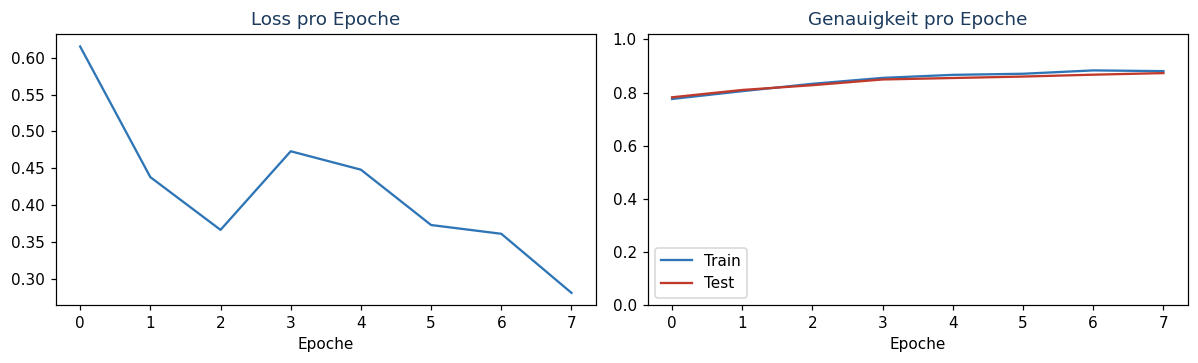

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(hist["loss"], color=MITTELBLAU); a1.set_title("Loss pro Epoche"); a1.set_xlabel("Epoche")
a2.plot(hist["train_acc"], color=MITTELBLAU, label="Train")
a2.plot(hist["test_acc"],  color=ROT,        label="Test")
a2.set_title("Genauigkeit pro Epoche"); a2.set_xlabel("Epoche"); a2.set_ylim(0, 1.02); a2.legend()
plt.tight_layout(); plt.show()

> 🔍 **Lösungshinweis (Deutung 2).** Nach 8 Epochen liegt die Test-Genauigkeit bei
> rund **86–88 %**. Train- und Test-Kurve liegen noch recht nah beieinander – mit
> diesem kleinen Netz und nur 8 Epochen ist das Overfitting moderat. Trainiert man
> viel länger, würde die Train-Kurve davonziehen.

## E · Auswertung *nach* dem Training

Die **Confusion Matrix** zeigt, welche Klassen verwechselt werden (Zeile = wahr,
Spalte = vorhergesagt).

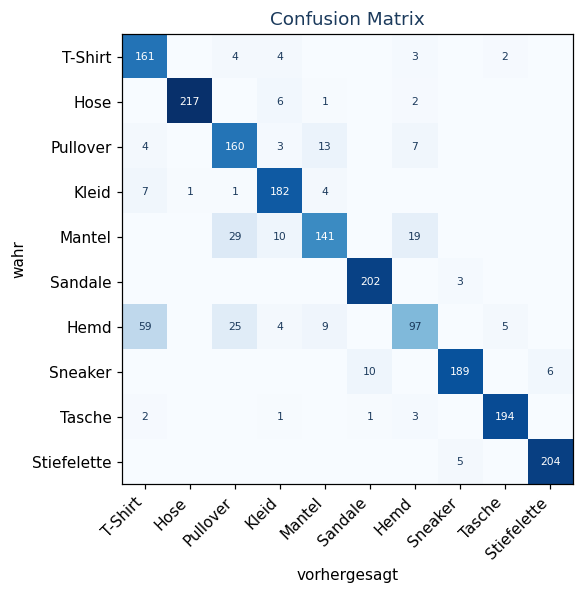

In [9]:
model.eval()
with torch.no_grad():
    pred = model(X_test).argmax(1)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(KLASSEN, rotation=45, ha="right"); ax.set_yticklabels(KLASSEN)
ax.set_xlabel("vorhergesagt"); ax.set_ylabel("wahr")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max()/2 else DUNKELBLAU)
ax.set_title("Confusion Matrix", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

> 🔍 **Lösungshinweis (Deutung 3).** Die stärksten Verwechslungen liegen wie
> vermutet bei den **Oberteilen**: typischerweise *Hemd → T-Shirt*, *Mantel →
> Pullover* und *Hemd → Pullover*. Grund ist die fast identische Silhouette – bei
> 28×28 Pixeln fehlen Details wie Knopfleiste oder Stoffdicke, an denen selbst
> Menschen diese Stücke unterscheiden. Das bestätigt die EDA-Hypothese.

Genauigkeit **je Klasse** – so sieht man, welche Stücke schwerfallen:

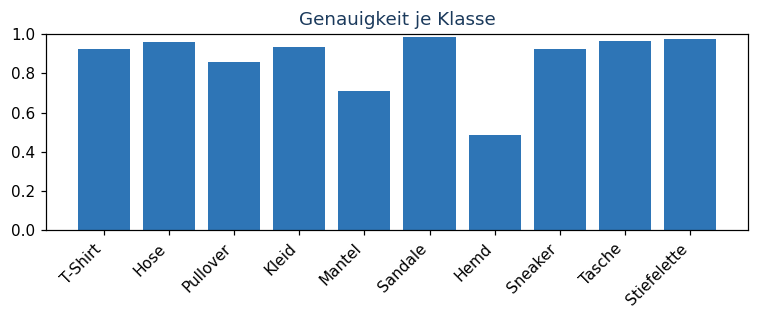

In [10]:
per_class = [(pred[y_test == k] == k).float().mean().item() for k in range(10)]
plt.figure(figsize=(7, 3))
plt.bar(KLASSEN, per_class, color=MITTELBLAU)
plt.xticks(rotation=45, ha="right"); plt.ylim(0, 1)
plt.title("Genauigkeit je Klasse"); plt.tight_layout(); plt.show()

Und ein Blick auf konkrete **Fehlklassifikationen**:

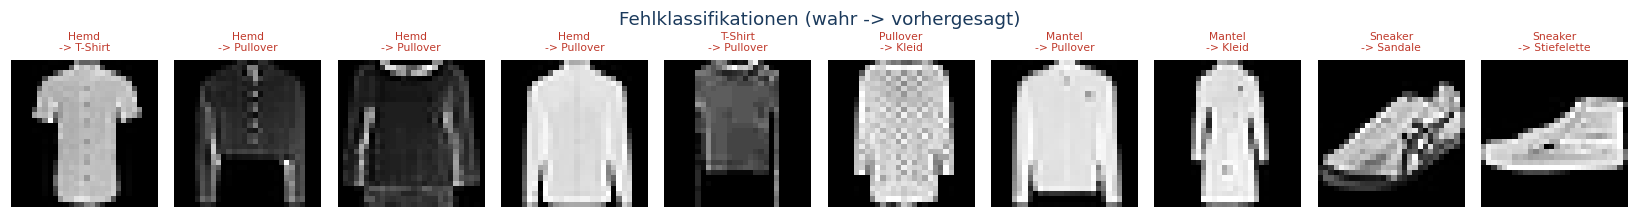

In [11]:
falsch = (pred != y_test).nonzero(as_tuple=True)[0][:10]
fig, axs = plt.subplots(1, len(falsch), figsize=(1.5*len(falsch), 2))
for j, k in enumerate(falsch):
    axs[j].imshow(X_test[k, 0], cmap="gray")
    axs[j].set_title(f"{KLASSEN[y_test[k]]}\n-> {KLASSEN[pred[k]]}", fontsize=7, color=ROT)
    axs[j].axis("off")
fig.suptitle("Fehlklassifikationen (wahr -> vorhergesagt)", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

## F · Feature Maps

Wie in Notebook 01: Ein `nn.Sequential` ist **schneidbar**, `model[:2]` wendet nur
Conv1 + ReLU an. So sehen wir die 16 Feature Maps der ersten Faltung.

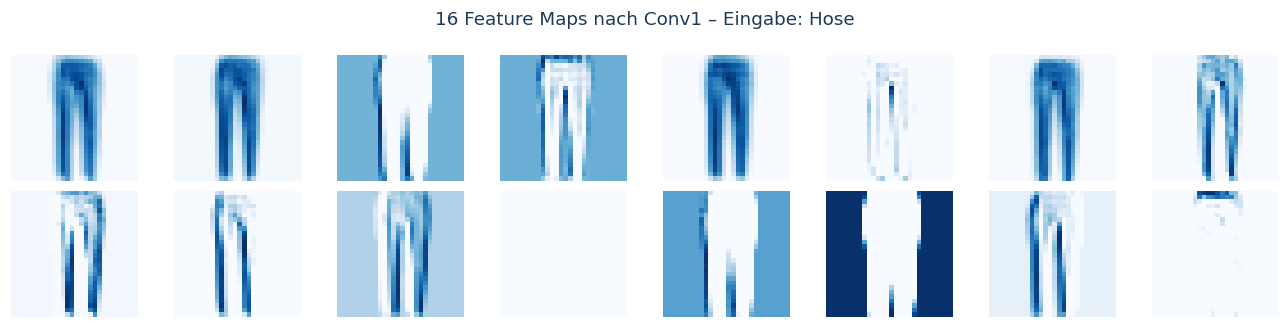

In [12]:
bild = X_test[0:1]
with torch.no_grad():
    feature_maps = model[:2](bild)      # nach Conv1 + ReLU: (1, 16, 28, 28)

fig, axs = plt.subplots(2, 8, figsize=(12, 3))
for i in range(16):
    axs[i//8, i%8].imshow(feature_maps[0, i], cmap="Blues")
    axs[i//8, i%8].axis("off")
fig.suptitle(f"16 Feature Maps nach Conv1 – Eingabe: {KLASSEN[y_test[0]]}", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

## G · Augmentierung – ⚖️ Entscheidung

Wir wollen die Trainingsdaten durch Augmentierung anreichern (wie bei den Gesichtern).
Aber nicht jede Transformation passt zu Kleidungsbildern.

> ⚖️ **Entscheidung.** Welche der folgenden Transformationen sind für Fashion-MNIST
> **gültig**? Begründe je kurz. Trage dann **nur die gültigen** in die `Compose`-Liste
> ein.
> - horizontales Spiegeln (links/rechts)
> - vertikales Spiegeln (oben/unten)
> - leichtes Drehen/Verschieben
> - 90°-Drehung

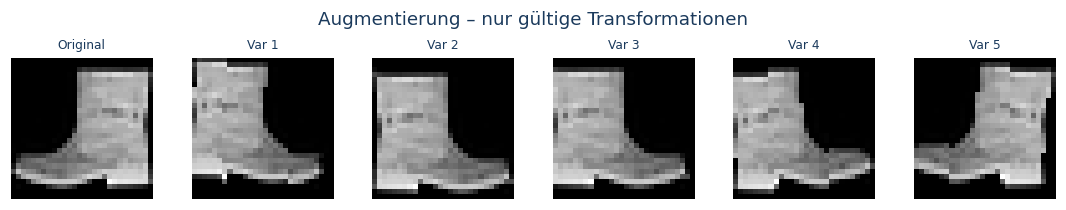

In [13]:
augment = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),                 # gültig: Kleidung ist ~links/rechts-symmetrisch
    v2.RandomAffine(degrees=8, translate=(0.06, 0.06)),  # gültig: leichtes Drehen/Verschieben
    # NICHT gültig: vertikales Spiegeln oder 90°-Drehung -> Kleidung steht dann auf dem Kopf
])

torch.manual_seed(0); b = X_train[0]
fig, axs = plt.subplots(1, 6, figsize=(10, 1.9))
axs[0].imshow(b[0], cmap="gray"); axs[0].set_title("Original", fontsize=8); axs[0].axis("off")
for i in range(1, 6):
    axs[i].imshow(augment(b)[0], cmap="gray"); axs[i].set_title(f"Var {i}", fontsize=8); axs[i].axis("off")
fig.suptitle("Augmentierung – nur gültige Transformationen", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

> ⚖️ **Lösungshinweis.** **Gültig:** horizontales Spiegeln (ein gespiegeltes T-Shirt
> bleibt ein realistisches T-Shirt) und leichtes Drehen/Verschieben. **Nicht gültig:**
> vertikales Spiegeln und 90°-Drehung – ein auf dem Kopf stehender Sneaker oder
> Pullover kommt real nicht vor und würde dem Netz falsche „Beispiele" zeigen.
> Merksatz: *Augmentierung muss zur Domäne passen.*

## H · 🐞 Fehlersuche

Die folgende Zelle **soll die Test-Genauigkeit berechnen**. Sie läuft ohne
Fehlermeldung – aber das Ergebnis wirkt **verdächtig hoch**.

> 🐞 **Aufgabe.** Finde den Fehler, korrigiere ihn, und erkläre in einem Satz, **warum**
> er das Ergebnis verfälscht.

In [14]:
model.eval()
with torch.no_grad():
    ausgabe = model(X_test)                 # korrigiert: Test- statt Trainingsdaten
    genauigkeit = (ausgabe.argmax(1) == y_test).float().mean().item()
print(f"Test-Genauigkeit: {genauigkeit*100:.1f}%")

Test-Genauigkeit: 87.3%


> 🐞 **Lösungshinweis.** Die Zelle wertet auf den **Trainingsdaten** (`X_train`,
> `y_train`) aus, behauptet aber, es sei die *Test*-Genauigkeit. Da das Netz die
> Trainingsbilder schon gesehen hat, ist der Wert geschönt. Korrekt sind `X_test` und
> `y_test`. Das ist ein klassischer Fall von **Datenleck** – und genau die Art Fehler,
> die KI-generierter Code nicht von selbst meldet: Der Code ist *syntaktisch korrekt*,
> nur *fachlich falsch*.

## Abschluss

Du hast einen vollständigen CNN-Workflow durchlaufen: **EDA → Modell → Training mit
Lernkurven → Auswertung (Confusion Matrix, Fehlerbilder, Feature Maps) →
Augmentierung**.

✍️ **Kurzreflexion (3 Sätze):**
1. Wie nah war deine Genauigkeits-Vorhersage?
2. Welche Klassen verwechselt das Netz – und warum?
3. Welcher Fehler steckte in Abschnitt H, und woran hättest du ihn auch ohne Hinweis
   erkennen können?